# 01 Baselines: Viterbi vs BCJR
## Цель ноутбука
Сравнить только классические baseline-декодеры без нейросетевых компонентов.

## Что делаем
Используем одинаковые сигналы и сравниваем Viterbi и BCJR по качеству декодирования и по времени работы.

## Что важно понять
- Viterbi обычно рассматривают как эффективный поиск наиболее вероятного пути в trellis.
- BCJR дает soft-оценки и часто выигрывает по качеству, но может быть тяжелее по времени.
- Этот ноутбук нужен как отправная точка перед сравнением с learned-подходами.

In [1]:
# [1/8] Импорты и поиск корня проекта
from pathlib import Path
import sys
import yaml
import pandas as pd
from IPython.display import display, Image

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    while cur != cur.parent:
        if (cur / 'pyproject.toml').exists():
            return cur
        cur = cur.parent
    raise RuntimeError('Repo root not found')

ROOT = find_repo_root(Path.cwd())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

print('[1/8] Импорты загружены')
print('ROOT =', ROOT)


[1/8] Импорты загружены
ROOT = C:\Users\maks\Desktop\maga\диплом\практика\2\dp-codex-create-repository-for-neural-viterbi-and-bcjr-j6ug56


# Настройка параметров эксперимента


In [2]:
# [2/8] Параметры эксперимента (редактируются в этой ячейке)
PARAMS = {
    'run_name': 'notebook_baseline_run',
    'K': 64,
    'num_blocks': 12,
    'snr_db_list': [0, 2],
    'seed': 123,
    'decoders': ['viterbi', 'bcjr'],
    'epochs': 1,
    'learning_rate': 1e-3,
    'hidden_dim': 16,
    'reuse_saved_signals': False,
    'training_enabled': False,
}
print('[2/8] Параметры заданы')
display(pd.Series(PARAMS))


[2/8] Параметры заданы


run_name               notebook_baseline_run
K                                         64
num_blocks                                12
snr_db_list                           [0, 2]
seed                                     123
decoders                     [viterbi, bcjr]
epochs                                     1
learning_rate                          0.001
hidden_dim                                16
reuse_saved_signals                    False
training_enabled                       False
dtype: object

In [3]:
# [3/8] Загружаем YAML, меняем параметры и сохраняем notebook-конфиг
from comm_ai.utils.io import load_yaml

cfg = load_yaml(ROOT / 'src/comm_ai/config/experiments/awgn_small.yaml')
cfg['experiment']['run_name'] = PARAMS['run_name']
cfg['experiment']['K'] = PARAMS['K']
cfg['experiment']['num_blocks'] = PARAMS['num_blocks']
cfg['experiment']['snr_db_list'] = PARAMS['snr_db_list']
cfg['experiment']['seed'] = PARAMS['seed']
cfg['experiment']['decoders'] = PARAMS['decoders']
cfg['experiment']['reuse_saved_signals'] = PARAMS['reuse_saved_signals']

# Все результаты ноутбуков сохраняем в корневую папку проекта, а не рядом с ноутбуком
cfg['paths']['outputs_root'] = str(ROOT / 'outputs' / 'runs')

cfg['training']['enabled'] = PARAMS['training_enabled']
cfg['training']['epochs'] = PARAMS['epochs']
cfg['training']['learning_rate'] = PARAMS['learning_rate']
cfg['training']['hidden_dim'] = PARAMS['hidden_dim']

nb_cfg_path = ROOT / 'outputs/runs' / f"{PARAMS['run_name']}_notebook_config.yaml"
nb_cfg_path.parent.mkdir(parents=True, exist_ok=True)
nb_cfg_path.write_text(yaml.safe_dump(cfg, sort_keys=False), encoding='utf-8')
print('[3/8] Конфиг сохранён в', nb_cfg_path)


[3/8] Конфиг сохранён в C:\Users\maks\Desktop\maga\диплом\практика\2\dp-codex-create-repository-for-neural-viterbi-and-bcjr-j6ug56\outputs\runs\notebook_baseline_run_notebook_config.yaml


### Краткое напоминание по алгоритмам
- `Viterbi` - ищет наиболее вероятный путь в trellis и дает одно итоговое решение.
- `BCJR` - вычисляет апостериорные вероятности битов и затем делает решение на их основе.

Практически это означает, что Viterbi часто оказывается быстрее, а BCJR нередко дает более качественное восстановление.

In [4]:
# [4/8] Пример сигнального pipeline: u -> c -> x -> noise -> y -> llr
from comm_ai.datasets.signals_dataset import SignalsDataset

ds_preview = SignalsDataset.generate(cfg)
print('[4/8] Preview dataset сгенерирован')
print('u[:16]     =', ds_preview.u[0][:16])
print('c[:16]     =', ds_preview.c[0][:16])
print('x[:16]     =', ds_preview.x[0][:16])
print('noise[:16] =', ds_preview.noise[0][:16])
print('y[:16]     =', ds_preview.y[0][:16])
print('llr[:16]   =', ds_preview.llr[0][:16])
print('Комментарий: чем меньше SNR, тем сильнее шум и сложнее декодирование.')


[4/8] Preview dataset сгенерирован
u[:16]     = [0 1 1 0 1 0 0 0 0 0 0 1 0 1 0 0]
c[:16]     = [0 0 1 1 1 0 0 1 0 0 0 1 0 1 1 0]
x[:16]     = [ 1.  1. -1. -1. -1.  1.  1. -1.  1.  1.  1. -1.  1. -1. -1.  1.]
noise[:16] = [ 1.22622929 -2.17204389 -0.37014735  0.16438007  0.85988118  1.76166124
  0.99332378 -0.29152143  0.72812756 -1.26160032  1.42993853 -0.15647532
 -0.67375915 -0.6390601  -0.06136133 -0.39278492]
y[:16]     = [ 2.22622929 -1.17204389 -1.37014735 -0.83561993 -0.14011882  2.76166124
  1.99332378 -1.29152143  1.72812756 -0.26160032  2.42993853 -1.15647532
  0.32624085 -1.6390601  -1.06136133  0.60721508]
llr[:16]   = [ 4.45245859 -2.34408777 -2.74029469 -1.67123986 -0.28023763  5.52332247
  3.98664755 -2.58304285  3.45625512 -0.52320063  4.85987705 -2.31295065
  0.6524817  -3.2781202  -2.12272266  1.21443015]
Комментарий: чем меньше SNR, тем сильнее шум и сложнее декодирование.


In [5]:
# [5/8] Запуск эксперимента
from comm_ai.experiments.run_experiment import run
out_dir = run(str(nb_cfg_path))
print('[5/8] Эксперимент завершён, артефакты в', out_dir)


[5/8] Эксперимент завершён, артефакты в outputs\runs\notebook_baseline_run


In [6]:
# [6/8] Таблица результатов и авто-анализ
from comm_ai.utils.reporting import analyze_results

results = pd.read_csv(out_dir / 'results.csv')
display(results)
a = analyze_results(results)
print('[6/8] Лучший BER:', a['best_ber'])
print('[6/8] Лучший FER:', a['best_fer'])
print('[6/8] Самый быстрый:', a['fastest'])
print('[6/8] Интерпретация:', a['tradeoff'])


,decoder,snr_db,ber,fer,decode_time_s,complexity_proxy,trained_model_used
0,bcjr,0.0,0.248698,0.833333,0.091009,4096,False
1,bcjr,2.0,0.022135,0.250000,0.090332,4096,False
2,viterbi,0.0,0.256510,0.833333,0.021950,4096,False
3,viterbi,2.0,0.022135,0.250000,0.021998,4096,False


[6/8] Лучший BER: bcjr
[6/8] Лучший FER: bcjr
[6/8] Самый быстрый: viterbi
[6/8] Интерпретация: По качеству (BER) лидирует `bcjr`, по скорости - `viterbi`. Наблюдается компромисс качество/время.


График BER
X: SNR [dB] - отношение мощности сигнала к мощности шума
Y: BER - доля ошибочно восстановленных битов


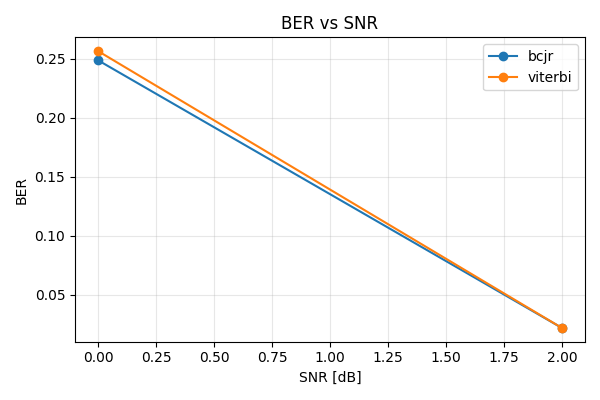

График FER
X: SNR [dB] - отношение мощности сигнала к мощности шума
Y: FER - доля блоков с хотя бы одной ошибкой


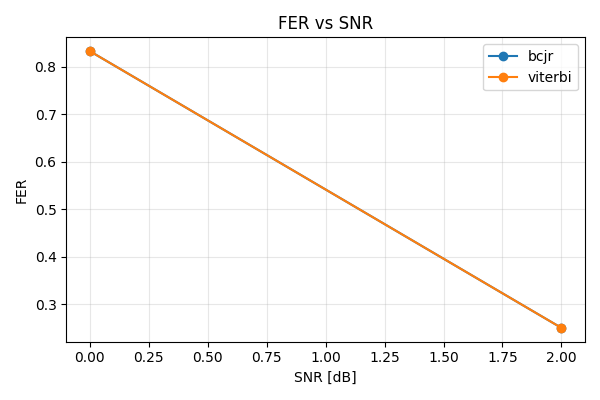

График времени декодирования
X: SNR [dB] - отношение мощности сигнала к мощности шума
Y: Decode time [s] - среднее время декодирования в секундах


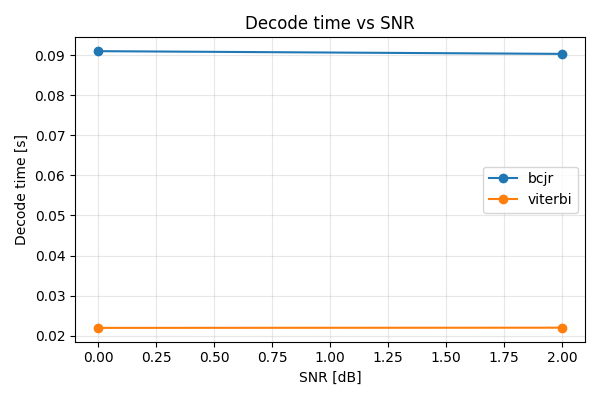

Краткий вывод по графикам:
- лучший BER: bcjr
- лучший FER: bcjr
- самый быстрый: viterbi


In [7]:
# [7/8] Графики с пояснением
print('График BER')
print('X: SNR [dB] - отношение мощности сигнала к мощности шума')
print('Y: BER - доля ошибочно восстановленных битов')
display(Image(filename=str(out_dir / 'ber_plot.png')))

print('График FER')
print('X: SNR [dB] - отношение мощности сигнала к мощности шума')
print('Y: FER - доля блоков с хотя бы одной ошибкой')
display(Image(filename=str(out_dir / 'fer_plot.png')))

print('График времени декодирования')
print('X: SNR [dB] - отношение мощности сигнала к мощности шума')
print('Y: Decode time [s] - среднее время декодирования в секундах')
display(Image(filename=str(out_dir / 'timing_plot.png')))

if 'results' in globals():
    grouped = results.groupby('decoder', as_index=False).agg(ber=('ber','mean'), fer=('fer','mean'), t=('decode_time_s','mean'))
    print('Краткий вывод по графикам:')
    print('- лучший BER:', grouped.loc[grouped['ber'].idxmin(), 'decoder'])
    print('- лучший FER:', grouped.loc[grouped['fer'].idxmin(), 'decoder'])
    print('- самый быстрый:', grouped.loc[grouped['t'].idxmin(), 'decoder'])


## Итог
После выполнения этого ноутбука у вас есть baseline для дальнейших сравнений. Именно с этими двумя алгоритмами затем сопоставляются Neural Viterbi и Neural BCJR.